## Angle-stack AVA inversion with guided DDPM — Otway synthetic benchmark

**Overview:** This notebook implements the full end-to-end prestack AVA inversion pipeline on the 2D Otway synthetic elastic model (128×256, nz×nx), comparing three methods:

1. **LSQR** — conventional least-squares inversion with Tikhonov damping
2. **ADMM+TV** — Alternating Direction Method of Multipliers with isotropic total-variation regularization
3. **DPS (Diffusion Posterior Sampling)** — guided reverse diffusion using a pretrained 3-channel DDPM as a physics-based generative prior

The Otway model is an **out-of-distribution** test case: the DDPM prior was trained on SEAM Arid, Overthrust, and Marmousi2 datasets, not on Otway (Sec. 1.3.5 of the report). This tests the generalization ability of the learned prior.

The notebook covers:
- Depth-to-time conversion and forward operator construction (Eqs. 1.2–1.7)
- Synthetic angle-stack data generation with zero noise (clean data experiment)
- LSQR and ADMM+TV inversion baselines
- DPS inversion with global normalization and deterministic DDIM (η=0)
- Quantitative comparison (SNR, SSIM) and 1D well-log comparison (Figure 1.3–1.4)

**Key difference from the UQ notebook:** This notebook focuses on single-realization inversion quality rather than ensemble-based uncertainty quantification. It uses **zero noise** (noise_std=0) and **deterministic DDIM** (η=0), targeting maximum reconstruction fidelity for the point-estimate comparison.

### 1. Imports and device setup

Core dependencies:
- `pylops`: matrix-free linear operators for the AVA forward model **G** (Eq. 1.7)
- `diffusers`: `UNet2DModel`, `DDPMScheduler`, `DDIMScheduler` for the DDPM prior
- `pyproximal`: proximal algorithms (`L21`, `ADMML2`) for the ADMM+TV baseline
- `diffavoinv.dps_avo_inversion1`: DPS guidance loop for single-realization inversion
  (note: uses `dps_avo_inversion1` rather than `dps_avo_inversion` — this version is optimized for deterministic DDIM)
- `diffavoinv.ddim_inversion_and_sampling`: unconditional DDIM sampler
- Device is auto-selected (GPU preferred for DDPM inference)

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import math
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import pylops
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from pylops.basicoperators import Identity, Laplacian
from diffusers import UNet2DModel, DDPMPipeline, DDPMScheduler, DDIMScheduler
from scipy.ndimage import gaussian_filter

from diffavoinv.dps_avo_inversion1 import *
from diffavoinv.ddim_inversion_and_sampling import *
from diffavoinv.utils import *

device = "cuda" if torch.cuda.is_available() else "cpu"

/home/dixita/anaconda3/envs/diffseisavo/lib/python3.9/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


### 2. Evaluation metric helpers

Defines the two quantitative metrics used in Section 1.4.1 of the report:
- `snr_db`: signal-to-noise ratio in dB — **SNR = 20 log10(||gt|| / ||gt − pred||)**. 
- `ssim_val`: structural similarity index (SSIM). 
- `power_iteration_norm`: estimates the spectral norm ||A||₂ via power iteration

In [186]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

def snr_db(gt, pred, eps=1e-12):
    num = np.linalg.norm(gt.ravel(), 2)
    den = np.linalg.norm((gt - pred).ravel(), 2)
    return 20.0 * np.log10((num) / (den + eps))

def ssim_val(gt, pred):
    dr = float(gt.max() - gt.min())
    if dr == 0:
        return 1.0
    return ssim(gt, pred, data_range=dr)


def power_iteration_norm(A, niter=30):
    x = np.random.randn(A.shape[1])
    x /= np.linalg.norm(x)

    for _ in range(niter):
        x = A.T @ (A @ x)
        x /= np.linalg.norm(x)

    Ax = A @ x
    return np.linalg.norm(Ax)

### 3. Depth-to-time conversion utility

The Otway model is defined in the depth domain. Since the DDPM prior and the AVA forward operator both operate in two-way traveltime (TWT), all elastic models are converted to TWT before inversion. The function preserves exactly nz=128 samples (nt = nz) so dimensions remain compatible with the pretrained DDPM (128×256 patches).

In [3]:
import numpy as np

def depth2time_same_pixels(vp, vs, rho, dz, vp_floor=500.0, use_smoothed_vp_for_mapping=False):
    """
    Convert depth-sampled elastic model to time-sampled model with SAME number of samples (nt = nz).
    dt is chosen automatically from global tmax (max bottom TWT across x).

    Inputs:
      vp, vs, rho: (nz, nx) or (nz,)
      dz: depth sampling in meters
      vp_floor: minimum vp to avoid division issues
      use_smoothed_vp_for_mapping: if True, use a simple vertical smoothing for mapping (optional)

    Returns:
      dt: scalar time sampling (seconds)
      t_grid: (nz,) global TWT grid
      vp_t, vs_t, rho_t: (nz, nx) time-resampled models (or (nz,) if input was 1D)
      t_twt: (nz, nx) per-trace TWT mapping from depth samples (useful for QC)
    """
    vp = np.asarray(vp, dtype=np.float64)
    vs = np.asarray(vs, dtype=np.float64)
    rho = np.asarray(rho, dtype=np.float64)

    is_1d = (vp.ndim == 1)
    if is_1d:
        vp = vp[:, None]; vs = vs[:, None]; rho = rho[:, None]

    nz, nx = vp.shape

    # --- optional: mild vertical smoothing for the time mapping only ---
    if use_smoothed_vp_for_mapping:
        # simple 1D moving average along z (no scipy)
        w = 9  # odd window
        ker = np.ones(w) / w
        vp_map = np.empty_like(vp)
        for ix in range(nx):
            vp_map[:, ix] = np.convolve(vp[:, ix], ker, mode="same")
    else:
        vp_map = vp

    vp_safe = np.maximum(vp_map, vp_floor)

    # TWT mapping for each trace: t(z,x) = 2 * cumsum(dz / vp)
    t_twt = 2.0 * np.cumsum(dz / vp_safe, axis=0)  # (nz, nx)

    # choose ONE global tmax so every trace shares the same time grid and dt
    tmax = float(np.nanmax(t_twt[-1, :]))  # bottom time, max over x
    dt = tmax / (nz - 1)

    t_grid = np.linspace(0.0, tmax, nz)  # (nz,)

    vp_t  = np.empty((nz, nx), dtype=np.float32)
    vs_t  = np.empty((nz, nx), dtype=np.float32)
    rho_t = np.empty((nz, nx), dtype=np.float32)

    for ix in range(nx):
        tt = t_twt[:, ix]
        tt = np.maximum.accumulate(tt)  # enforce monotonicity

        # interpolate depth-sampled properties onto the common time grid
        vp_t[:, ix]  = np.interp(t_grid, tt, vp[:, ix]).astype(np.float32)
        vs_t[:, ix]  = np.interp(t_grid, tt, vs[:, ix]).astype(np.float32)
        rho_t[:, ix] = np.interp(t_grid, tt, rho[:, ix]).astype(np.float32)

    if is_1d:
        return dt, t_grid, vp_t[:, 0], vs_t[:, 0], rho_t[:, 0], t_twt[:, 0]

    return dt, t_grid, vp_t, vs_t, rho_t, t_twt

---
## Part I: Pretrained DDPM prior — load and verify

### 4. Load pretrained 3-channel DDPM and DDPM scheduler

In [ ]:

load_dir = Path('/home/dixita/dpsAVOinversion-dev/data/checkpoints/3ch-ddpm-20260429-154107') # updated checkpoint with global normalization--with 500 epoch

# UNet
model = UNet2DModel.from_pretrained(load_dir).to(device)

# Scheduler (note the subfolder)
scheduler = DDPMScheduler.from_pretrained(load_dir / "scheduler")

assert scheduler.config.prediction_type == "epsilon"          # or whatever you trained with
assert scheduler.config.num_train_timesteps == 1000           # match training

In [ ]:
from diffusers import DDIMScheduler

# Inherit all training config (beta schedule, num_train_timesteps, prediction_type)
scheduler = DDIMScheduler.from_pretrained(load_dir / "scheduler")

# Verify config matches training
assert scheduler.config.prediction_type == "epsilon"
assert scheduler.config.num_train_timesteps == 1000

# Set inference steps (much fewer than 1000 needed)
scheduler.set_timesteps(200)  # start with 200, can go as low as 50

### 5. Generate unconditional DDIM samples (qualitative prior check)

In [230]:
# Number of time steps for sampling:
num_inference_steps=100
scheduler.set_timesteps(num_inference_steps)
                                                      
n_gen=5
unconditionals_samples = []
for gen in range(n_gen):
    # Unconditional DDIM sampling
    generated = sample_unconditional(model, scheduler, num_inference_steps,  device=device, shape=(1,3,128,256))
    unconditional_sample_np = generated[0,0].detach().cpu().numpy()
    unconditionals_samples.append(generated)


### 6. Visualize unconditional prior samples

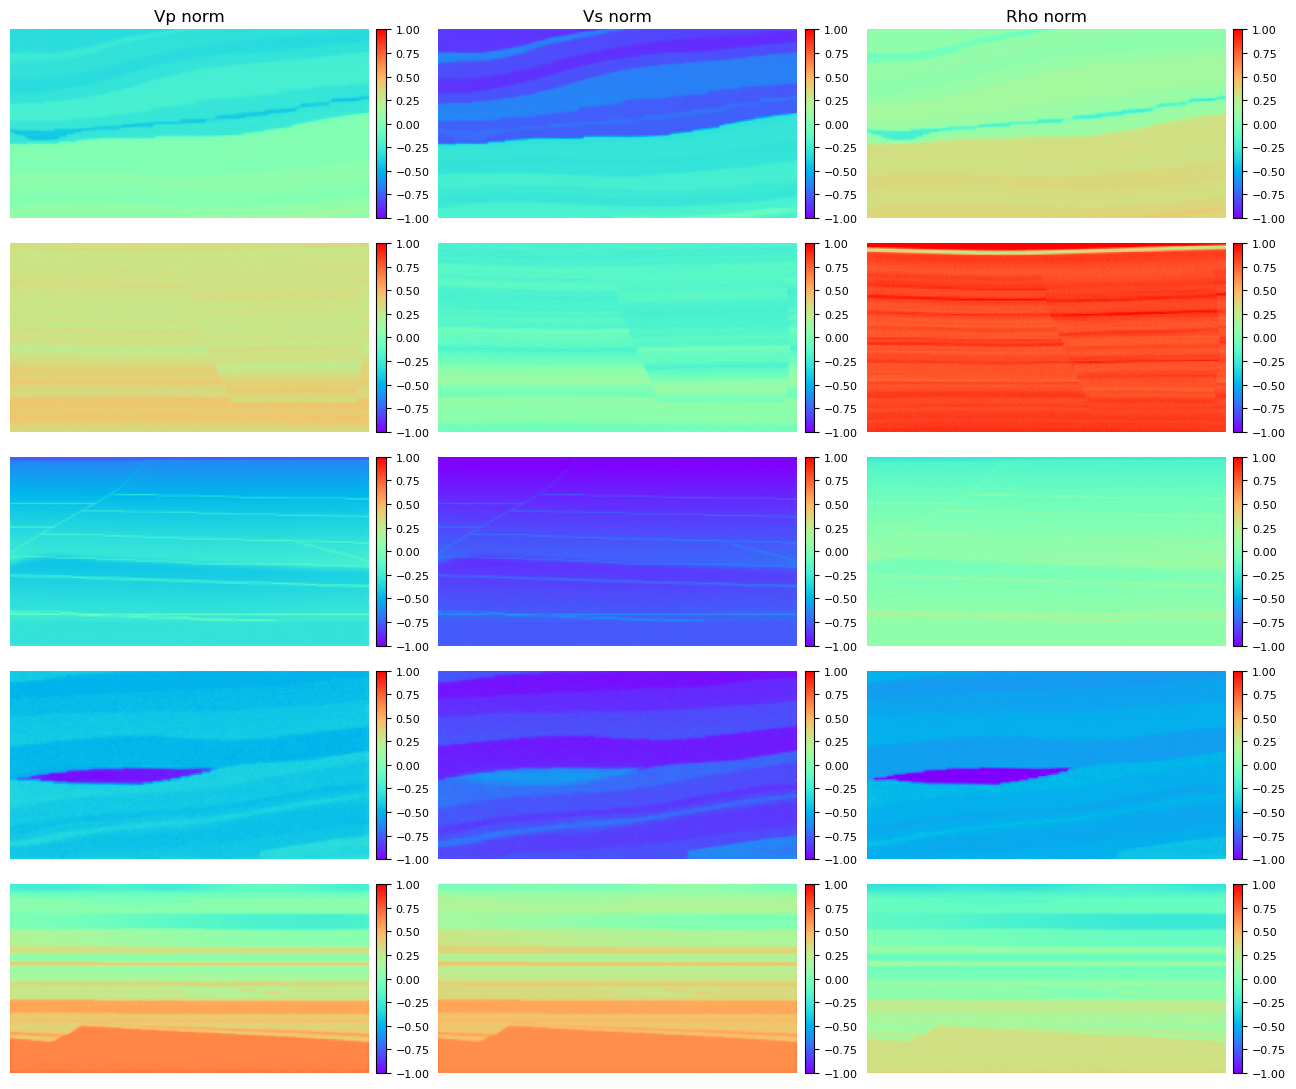

In [231]:
import numpy as np
import matplotlib.pyplot as plt

# --- Visualization parameters ---
vmin, vmax = -1, 1
cmap = "rainbow"

# --- Convert tensors to numpy ---
# Each sample: (3, H, W)
samples_np = [s[0].detach().cpu().numpy() for s in unconditionals_samples]
n_samples = len(samples_np)

# --- Column titles ---
col_titles = ["Vp norm", "Vs norm", "Rho norm"]

# --- Create figure (wide panels) ---
fig, axes = plt.subplots(
    nrows=n_samples,
    ncols=3,
    figsize=(13, 2.2 * n_samples),  # <<< wider than tall


    squeeze=False
)

for i in range(n_samples):        # rows → samples
    for j in range(3):            # cols → channels
        ax = axes[i, j]

        im = ax.imshow(
            samples_np[i][j],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            aspect="auto"        
        )

        ax.axis("off")

        # Titles only on first row
        if i == 0:
            ax.set_title(col_titles[j], fontsize=12)

        # Colorbar for each subplot
        cbar = fig.colorbar(
            im,
            ax=ax,
            fraction=0.035,
            pad=0.02
        )
        cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


---
## Part II: Otway model loading and depth-to-time conversion

### 7. Load Otway elastic model (depth domain)

vp min/max: 1475.833251953125 3709.880126953125
vs min/max: 626.111083984375 2136.875732421875
rho min/max: 1788.888916015625 3474.852294921875
Vp (m/s) mean: 2684.6274985149503
Vp (m/s) std: 573.063338913147
Vs (m/s) mean: 1281.0450999438763
Vs (m/s) std: 404.69317868583346
Rho (m/s) mean: 2226.731957901269
Rho (m/s) std: 169.31123634507566


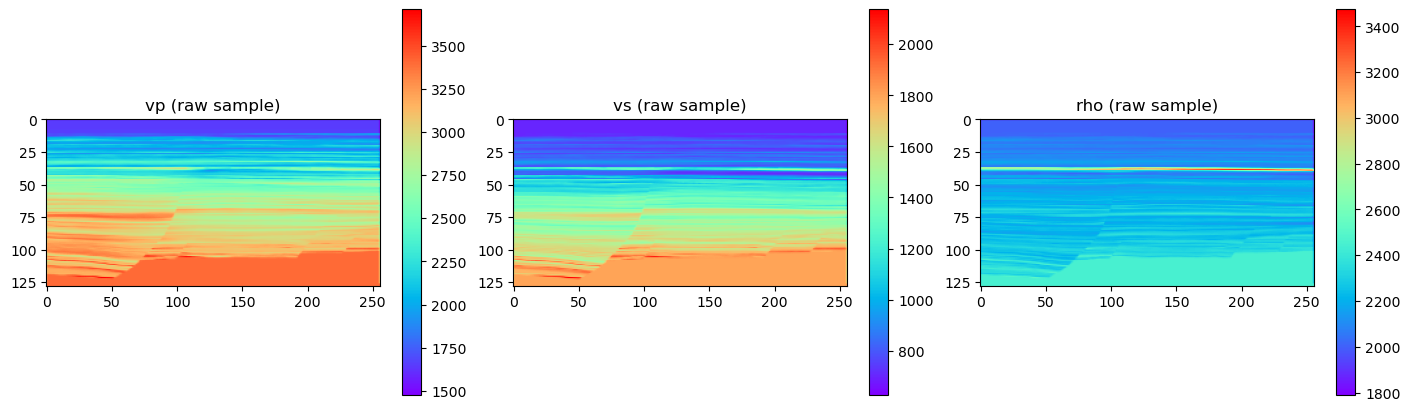

In [26]:
# Load a sample from the dataset:
file = np.load('../data/C_Otway2D/otway_128_256.npz')
# print(sample.shape, sample.dtype)

vp = file['m'][0].astype(np.float64)
vs = file['m'][1].astype(np.float64)
rho = file['m'][2].astype(np.float64) # keeping in kg/m3

vp[-2:,:] = 3400
vs[-2:,:] = 1800.0
rho[-2:,:] = 2450

vmin_true = [vp.min(), vs.min(), rho.min()]
vmax_true = [vp.max(), vs.max(), rho.max()]

x, z = file['x'], file['z']
nz,nx = vp.shape
dz, dx = z[1]-z[0], x[1]-x[0]

# print("Loaded sample shape:", sample.shape, " -> nz,nx =", nz, nx)
print("vp min/max:", vp.min(), vp.max())
print("vs min/max:", vs.min(), vs.max())
print("rho min/max:", rho.min(), rho.max())

mean_model = vp.mean(); print("Vp (m/s) mean:",mean_model )
std_model  = vp.std(); print("Vp (m/s) std:", std_model)
mean_model = vs.mean(); print("Vs (m/s) mean:",mean_model )
std_model  = vs.std(); print("Vs (m/s) std:", std_model)
mean_model = rho.mean(); print("Rho (m/s) mean:",mean_model )
std_model  = rho.std(); print("Rho (m/s) std:", std_model)

# 9a) show vp/vs/rho patches (input)
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
im = axs[0].imshow(vp, cmap='rainbow');  axs[0].set_title("vp (raw sample)");  plt.colorbar(im, ax=axs[0])
im = axs[1].imshow(vs, cmap='rainbow');  axs[1].set_title("vs (raw sample)");  plt.colorbar(im, ax=axs[1])
im = axs[2].imshow(rho, cmap='rainbow'); axs[2].set_title("rho (raw sample)"); plt.colorbar(im, ax=axs[2])
plt.show()

### 8. Convert Otway model from depth to TWT domain

Calls `depth2time_same_pixels` to convert the depth-domain Vp, Vs, and ρ to the TWT domain. The function preserves nz=128 samples so that the converted model remains compatible with the DDPM grid dimensions.

In [27]:
# Covert Otway in time domain:
dt, t, vp_t, vs_t, rho_t, tmap = depth2time_same_pixels(vp, vs, rho, dz)

print("nt (time samples) =", vp_t.shape[0], "should equal nz")
print("auto dt =", dt, "seconds")

extent = [x[0], x[-1], t[-1], t[0]]


nt (time samples) = 128 should equal nz
auto dt = 0.013071403046346311 seconds


### 9. Display true elastic parameters in TWT domain

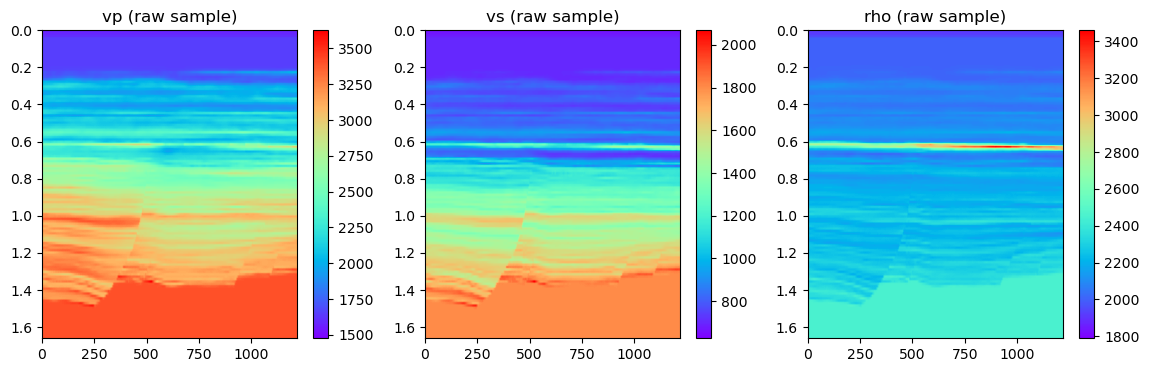

In [28]:
# 9a) show vp/vs/rho patches (input)
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=False)
im = axs[0].imshow(vp_t, cmap='rainbow',  extent=extent);  axs[0].set_title("vp (raw sample)");  plt.colorbar(im, ax=axs[0]); axs[0].axis('tight')
im = axs[1].imshow(vs_t, cmap='rainbow' , extent=extent);  axs[1].set_title("vs (raw sample)");  plt.colorbar(im, ax=axs[1]); axs[1].axis('tight')
im = axs[2].imshow(rho_t, cmap='rainbow', extent=extent); axs[2].set_title("rho (raw sample)"); plt.colorbar(im, ax=axs[2]); axs[2].axis('tight')
plt.show()

### 10. Stack and transpose time-domain model for saving

In [ ]:
model_time = np.dstack((vp_t, vs_t, rho_t))
model_time.shape

model_time1 = model_time.transpose((2,0,1))
model_time1.shape

np.save("../data/C_Otway2D/model_time.npy", model_time1)

(3, 128, 256)

---
## Part III: AVA forward operator, synthetic data generation, and inversion setup

Constructs the full linearized Aki-Richards AVA forward operator **G** (Eqs. 1.2–1.7 of the report), generates clean synthetic angle-stack data (noise_std=0), and builds the smooth background model used as the initial model for all three inversion methods. This closely follows the experimental setup described in Section 1.4.1.

### 11. Log parameterization, background model, wavelet, operator, and angle stacks

**Log-domain model (m):** Following Eq. 1.8, the elastic model is parameterized as m = [ln Vp, ln Vs, ln ρ]^T. The true log-model is also saved to disk (`model_t.npy`) for use by other scripts.

**Background model (mback):** Gaussian-smoothed version of the true log-model with σ_z=8 and σ_x=12 samples. Serves as the low-frequency initial model (prior mean μ) for LSQR, ADMM+TV, and DPS warm-start.

**Ricker wavelet:** Peak frequency f0=150 Hz; dt0=0.0131 s (matching the auto-computed dt from the depth-to-time conversion). Length ntwav=11 keeps the operator compact while capturing the main wavelet lobe.

**Angle range:** θ ∈ [5°, 45°] with ntheta=27 angles — **wider than the UQ notebook** (3°–30°), extending to larger offsets.

**PrestackLinearModelling (PPop):** Matrix-free operator G ∈ R^(Nθ·nz × 3N) using Aki-Richards linearization ("akirich", Eqs. 1.3–1.5). `explicit=False` uses adjoint operations, avoiding dense matrix storage.

**Synthetic data:** Forward model dPP is computed noise-free (noise_std=0), in contrast to the 3% Gaussian noise added in Sec. 1.4.1. This isolates inversion quality from noise sensitivity.

**Angle stacks:** Bin edges [5°, 10°, 20°, 45°] produce near (5°–10°), mid (10°–20°), and far (20°–45°) stacks. The far stack covers a wider angle range than in the UQ notebook (20°–45° vs. 20°–30°), providing stronger Vs and density sensitivity. The compact 3-angle operator G at bin-centre angles is used for all inversions and DPS guidance.

The combined figure (rows: true elastic params / angle stacks) corresponds to Figure 1.2 of the report.

m shape: (128, 3, 256)
wav length: 11
Operator shape: (884736, 98304) (data_size, model_size)
mvec: (98304,) dvec: (884736,)
dPP: (128, 27, 256) dPPn: (128, 27, 256)
ithetas: [0, 4, 10, 26] counts: [ 4  6 16]
stacks shape: (128, 3, 256)


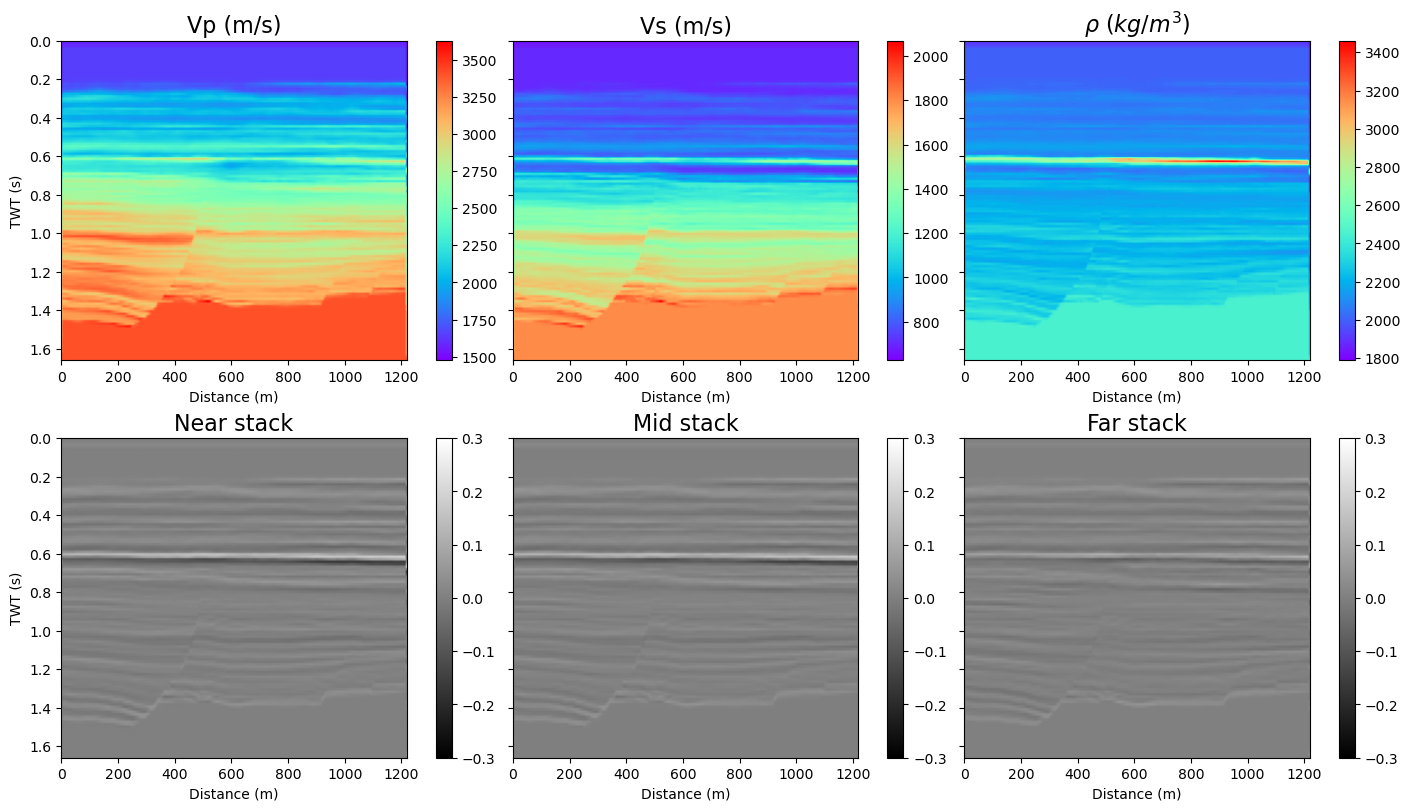

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import pylops
from pylops.utils.wavelets import ricker

# -------------------------------------
# Build true model 'm' in log domain:
# -------------------------------------
m = np.log(np.stack((vp_t, vs_t, rho_t), axis=1))  # (nz, 3, nx)
print("m shape:", m.shape)

np.save('../data/C_Otway2D/model_t.npy', m)

# -------------------------------------
# Smooth 'm' for initial model mback
# -------------------------------------
sigma_z = 8.0     # vertical smoothing (samples)
sigma_x = 12.0    # lateral smoothing  (samples)

mback = np.empty_like(m)
for ip in range(3):
    mback[:, ip, :] = gaussian_filter(
        m[:, ip, :], sigma=(sigma_z, sigma_x), mode="nearest"
    )

# -------------------------
# Wavelet and angles
# -------------------------
dt0 = 0.0131#dt  # s
f0 = 150.0
ntwav = 11

tw = (np.arange(ntwav) - ntwav // 2) * dt0
wav = ricker(tw, f0=f0)[0][:ntwav]
print("wav length:", len(wav))

# Use DEGREES for angle definition (consistent with bin_edges_deg)
ntheta = 27
theta_min_deg, theta_max_deg = 5.0, 45.0   # IMPORTANT: must cover your bins
theta_deg = np.linspace(theta_min_deg, theta_max_deg, ntheta)

# -------------------------
# Build linear operator
# -------------------------
PPop = pylops.avo.prestack.PrestackLinearModelling(
    wav,
    theta_deg,
    nt0=nz,
    spatdims=(nx,),
    linearization="akirich",
    explicit=False,
)
print("Operator shape:", PPop.shape, "(data_size, model_size)")

# -------------------------
# Forward model data dPP(z, theta, x)
# -------------------------
assert m.shape == (nz, 3, nx), m.shape

mvec = m.ravel(order="C")
dvec = PPop * mvec
dPP = dvec.reshape(nz, ntheta, nx, order="C")

# Add noise (in gather domain)
noise_std = 3e-2
rng = np.random.default_rng(0)
dPPn = dPP + rng.normal(0.0, noise_std, size=dPP.shape)

print("mvec:", mvec.shape, "dvec:", dvec.shape)
print("dPP:", dPP.shape, "dPPn:", dPPn.shape)

# -------------------------
# Angle stacks (near/mid/far)
# -------------------------
bin_edges_deg = [int(theta_min_deg), 10, 20, int(theta_max_deg)]  # must lie within [theta_min_deg, theta_max_deg]
ithetas = [np.searchsorted(theta_deg, e, side="left") for e in bin_edges_deg]

# check bins are non-empty
counts = np.diff(ithetas)
print("ithetas:", ithetas, "counts:", counts)
if np.any(counts == 0):
    raise ValueError(f"Empty angle bin detected. ithetas={ithetas}, theta_deg range={theta_deg[0]}–{theta_deg[-1]}")

# Stack the NOISY gathers (this is what you'd have in practice)
dPPn_stacks = np.stack(
    [dPPn[:, ithetas[i]:ithetas[i+1], :].mean(axis=1) for i in range(len(ithetas) - 1)],
    axis=1
)  # (nz, nbins, nx)

print("stacks shape:", dPPn_stacks.shape)  # (nz, 3, nx)



thetas3_deg = np.array([(bin_edges_deg[0]+bin_edges_deg[1])/2, 
                        (bin_edges_deg[1]+bin_edges_deg[2])/2, 
                        (bin_edges_deg[2]+bin_edges_deg[3])/2]
                        , dtype=float)
# theta3 = np.deg2rad(thetas3_deg)

G =  pylops.avo.prestack.PrestackLinearModelling(
    wav, thetas3_deg, nt0=128, spatdims=(nx,),
    linearization="akirich",
    explicit=False
)

# -------------------------
# Plot true elastic model & near/mid/far stacks in time-domain---------------Fig. 1
# -------------------------
titles = ["Near stack", "Mid stack", "Far stack"]
clip = 0.3
titles1 = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ ($kg/m^3$)"]
fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True, sharey=True)
for i in range(3):
    im0 = axs[0,i].imshow(
        np.exp(m[:, i, :]),
        cmap="rainbow",
        aspect="auto",
        origin="upper",
        vmin=np.exp(m[:, i, :].min()), vmax=np.exp(m[:, i, :].max()),
        extent=extent
    )
    axs[0,i].set_title(titles1[i], fontsize=16)
    axs[0,i].set_xlabel("Distance (m)")
    axs[0,0].set_ylabel("TWT (s)")
    plt.colorbar(im0, ax=axs[0,i])

    im1 = axs[1,i].imshow(
        dPPn_stacks[:, i, :],
        cmap="gray",
        aspect="auto",
        origin="upper",
        vmin=-clip, vmax=clip,
        extent=extent
    )
    axs[1,i].set_title(titles[i], fontsize=16)
    axs[1,i].set_xlabel("Distance (m)")
    axs[1,0].set_ylabel("TWT (s)")
    plt.colorbar(im1, ax=axs[1,i])



plt.show()

---
## Part IV: Conventional deterministic inversion baselines

Implements the two conventional deterministic inversion methods described in Section 1.4.1 of the report: LSQR and ADMM+TV. These serve as baselines against which DPS reconstruction quality is quantitatively compared (SNR and SSIM in Figure 1.3).

### 12. LSQR inversion

Runs the `pylops.avo.prestack.PrestackInversion` solver using LSQR — the standard least-squares QR algorithm that minimizes ||G m − d||² + damp²||m||² starting from the smooth background model `mback`.

Key parameters:
- `damp=0.7`: Tikhonov regularization weight; stabilizes the ill-conditioned AVO system (Vp–Vs–ρ cross-talk is a known issue without regularization)
- `iter_lim=500`: maximum LSQR iterations
- `m0=mback`: warm-start from the smooth background, providing the low-frequency trend that seismic data cannot recover alone

minv shape: (128, 3, 256) dres shape: (128, 3, 256)


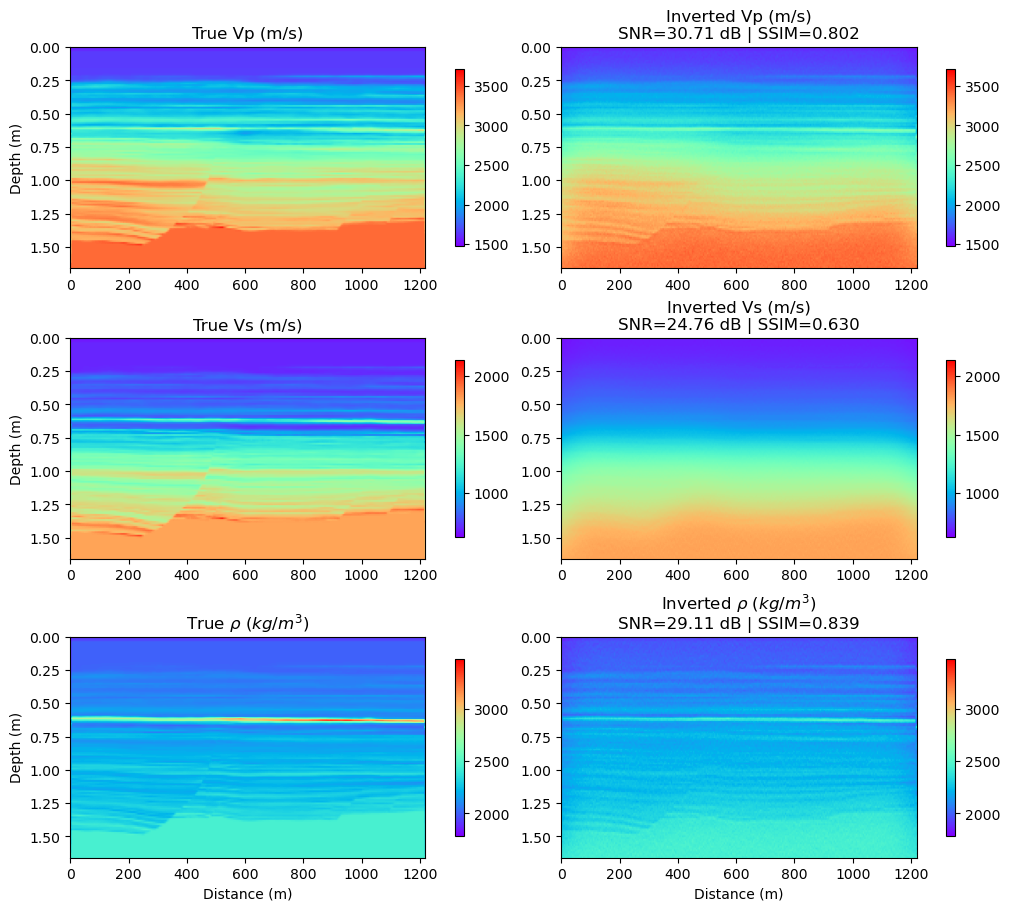

In [177]:

# -------------------------
# Invert back to minv(z, 3, x)
# -------------------------
minv, dres = pylops.avo.prestack.PrestackInversion(
    dPPn_stacks,                 # (nz, ntheta, nx)
    thetas3_deg,
    wav,
    m0=mback,             # (nz, 3, nx)
    linearization="akirich",
    explicit=False,
    returnres=True,
    **dict(damp=.7, iter_lim=500)
)

print("minv shape:", minv.shape, "dres shape:", dres.shape)

# -------------------------
# forward from inverted model to check data fit
# -------------------------
# minv_vec = minv.ravel(order="C")
# dvec_pred = PPop * minv_vec
# dPP_pred = dvec_pred.reshape(nz, ntheta, nx, order="C")

# minv_log = np.empty_like(minv)

minv_phy_vp = np.exp(minv[:, 0, :])  # Vp
minv_phy_vs = np.exp(minv[:, 1, :])  # Vs
minv_phy_rho = np.exp(minv[:, 2, :])  # Rho
minv_phy = np.stack([minv_phy_vp, minv_phy_vs, minv_phy_rho ], axis=0)


titles = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ $(kg/m^3)$"]
vmin_true = [vp.min(), vs.min(), rho.min()]
vmax_true = [vp.max(), vs.max(), rho.max()]
fig, axs = plt.subplots(3, 2, figsize=(10, 9), constrained_layout=True)

for i in range(3):
    im0 = axs[i, 0].imshow(np.exp(m[:, i, :]), aspect="auto", cmap="rainbow", vmin=vmin_true[i], vmax=vmax_true[i], extent=extent)
    axs[i, 0].set_title(f"True {titles[i]}")
    axs[i, 0].set_ylabel("Depth (m)")
    plt.colorbar(im0, ax=axs[i, 0], shrink=0.8)

    im1 = axs[i, 1].imshow(np.exp(minv[:, i, :]), aspect="auto", cmap="rainbow", vmin=vmin_true[i], vmax=vmax_true[i], extent=extent)
    
    snr_val = snr_db(np.exp(m[:, i, :]), np.exp(minv[:, i, :]) )
    ssim_score = ssim_val(np.exp(m[:, i, :]), np.exp(minv[:, i, :]) )
    axs[i, 1].set_title(f"Inverted {titles[i]}"+ f"\nSNR={snr_val:.2f} dB | SSIM={ssim_score:.3f}" )
    
    plt.colorbar(im1, ax=axs[i, 1], shrink=0.8)

axs[-1, 0].set_xlabel("Distance (m)")
axs[-1, 1].set_xlabel("Distance (m)")
plt.show()

### 13. ADMM+TV inversion

Implements the ADMM with isotropic total-variation regularization, solving:
  min ||G m − d||² + λ_TV · ||[Dz; Dx] m||_{2,1}

**TV operator:** Isotropic 2D TV uses third-order first-derivative operators along depth (Dz) and lateral (Dx) axes, stacked via `pylops.VStack`. The third-order derivative (`order=3`) provides better isotropy than the standard first-order operator.

**ADMM parameters:**
- `lambda_tv=8e-3`: TV regularization weight, tuned to balance noise suppression and boundary sharpness
- `tau=1.0`: ADMM step size (the spectral norm `Anorm` is computed via power iteration but the step size is set to a fixed value here)
- `niter=200`, `iter_lim=200`: outer ADMM and inner LSQR iterations
- `damp=0.7`: same damping as LSQR for the x-update subproblem

In [178]:
import numpy as np
import pylops
from pyproximal import L21
from pyproximal.optimization.primal import ADMML2

# Model size
nmodel = nz * 3 * nx

G = pylops.avo.prestack.PrestackLinearModelling(
    wav,
    thetas3_deg,
    nt0=128,
    spatdims=(nx,),
    linearization="akirich",
    explicit=False,
)

# Derivatives on the full (nz, 3, nx) cube (only z and x axes!)
Dz = pylops.FirstDerivative(dims=(nz, 3, nx), axis=0, sampling=1, edge=True, order=3, dtype="float64")
Dx = pylops.FirstDerivative(dims=(nz, 3, nx), axis=2, sampling=1, edge=True, order=3, dtype="float64")

# Prox for isotropic TV: || [Dz x; Dx x] ||
# A stacks the gradients: z = [Dz x; Dx x] and weights the gradient based on the dz,dz spacings:
# wz, wx = dt0, dx
A = pylops.VStack([Dz,Dx])

# scaling the thresholding by dx
lambda_tv = 8e-3 #8e-3
proxg = L21(ndim=2, sigma=lambda_tv)

# ADMM step size condition depends on A^H A; safe is tau <= 1 / lambda_max(A^H A)
# In practice start conservative:
Anorm = power_iteration_norm(A)
tau = 1.0 #/ (Anorm**2 + 1e-12)

# Run ADMM
x_admm, z_admm = ADMML2(
    proxg,
    Op=G,
    b=dPPn_stacks.ravel(order="C"),
    A=A,
    x0=mback.ravel(order="C"),         # x0 should be log-space background vector
    tau=tau,
    niter=200,
    show=True,
    # kwargs for SciPy lsqr used internally in x-update
    iter_lim=200,
    damp=0.7,
    atol=1e-6,
    btol=1e-6,
)

mhat = x_admm.reshape(nz, 3, nx, order="C")

madmmtv_phy_vp = np.exp(mhat[:, 0, :]) # Vp
madmmtv_phy_vs = np.exp(mhat[:, 1, :])  # Vs
madmmtv_phy_rho = np.exp(mhat[:, 2, :])  # Rho
madmmtv_phy = np.stack([madmmtv_phy_vp, madmmtv_phy_vs, madmmtv_phy_rho ], axis=0)


ADMM
---------------------------------------------------------
Proximal operator (g): <class 'pyproximal.proximal.L21.L21'>
tau = 1.000000e+00	niter = 200

   Itn       x[0]          f           g       J = f + g
     1   7.35025e+00   1.368e+01   5.997e+00   1.968e+01
     2   7.35454e+00   1.100e+01   6.244e+00   1.724e+01
     3   7.35759e+00   9.284e+00   6.690e+00   1.597e+01
     4   7.36000e+00   8.542e+00   6.997e+00   1.554e+01
     5   7.36221e+00   8.168e+00   7.169e+00   1.534e+01
     6   7.36428e+00   7.953e+00   7.262e+00   1.522e+01
     7   7.36614e+00   7.815e+00   7.313e+00   1.513e+01
     8   7.36784e+00   7.721e+00   7.338e+00   1.506e+01
     9   7.36942e+00   7.656e+00   7.346e+00   1.500e+01
    10   7.37092e+00   7.608e+00   7.342e+00   1.495e+01
    21   7.38253e+00   7.344e+00   7.255e+00   1.460e+01
    41   7.39022e+00   7.135e+00   7.181e+00   1.432e+01
    61   7.39400e+00   7.064e+00   7.131e+00   1.420e+01
    81   7.39652e+00   7.041e+00   7.077e+00  

### 14. Visualize and quantify ADMM+TV results

Inverted Vp (m/s)
SNR=29.25 dB | SSIM=0.838
Inverted Vs (m/s)
SNR=20.37 dB | SSIM=0.611
Inverted $\rho$ $(kg/m^3)$
SNR=30.39 dB | SSIM=0.838


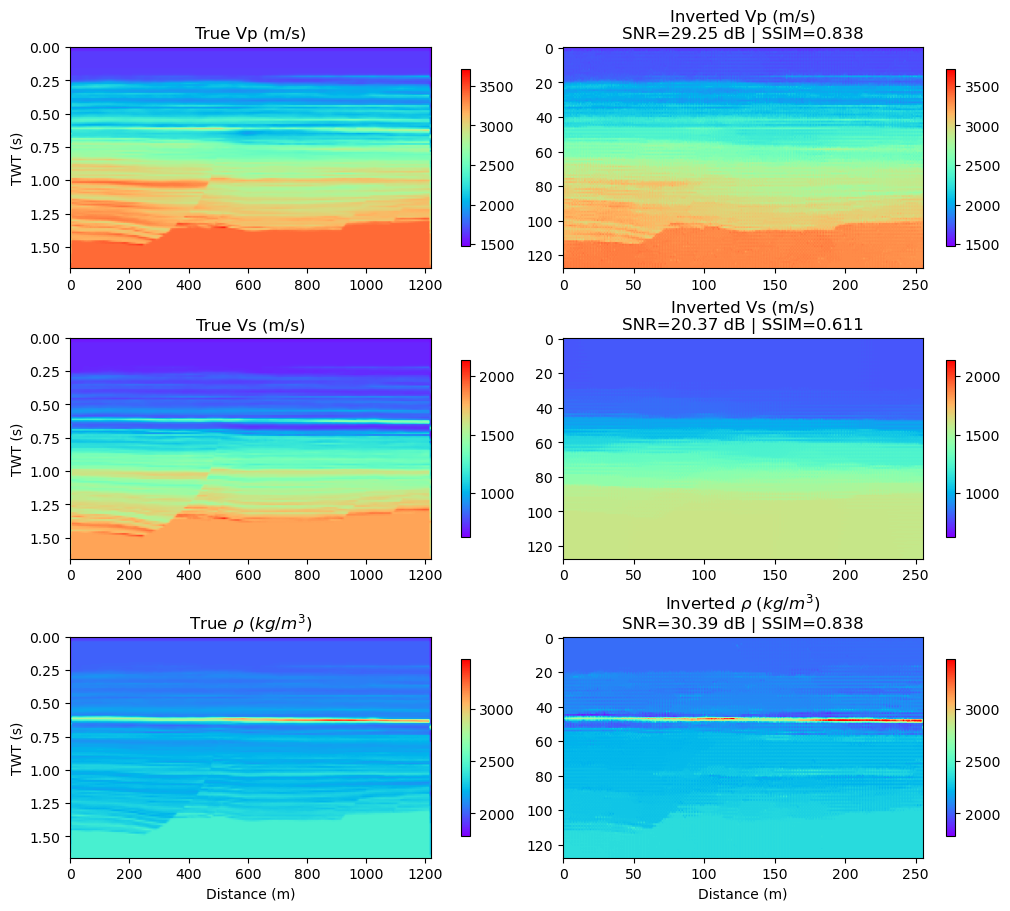

In [180]:
titles = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ $(kg/m^3)$"]
vmin_true = [vp.min(), vs.min(), rho.min()]
vmax_true = [vp.max(), vs.max(), rho.max()]
fig, axs = plt.subplots(3, 2, figsize=(10, 9), constrained_layout=True)

for i in range(3):
    im0 = axs[i, 0].imshow(np.exp(m[:, i, :]), aspect="auto", cmap="rainbow", vmin=vmin_true[i], vmax=vmax_true[i], extent=extent )
    axs[i, 0].set_title(f"True {titles[i]}")
    axs[i, 0].set_ylabel("TWT (s)")
    plt.colorbar(im0, ax=axs[i, 0], shrink=0.8)

    im1 = axs[i, 1].imshow(madmmtv_phy[i,:,:], aspect="auto", cmap="rainbow", vmin=vmin_true[i], vmax=vmax_true[i] )
    snr_val = snr_db(np.exp(m[:, i, :]), madmmtv_phy[i,:,:] )
    ssim_score = ssim_val(np.exp(m[:, i, :]), madmmtv_phy[i,:,:] )
    axs[i, 1].set_title(f"Inverted {titles[i]}"+ f"\nSNR={snr_val:.2f} dB | SSIM={ssim_score:.3f}" )
    plt.colorbar(im1, ax=axs[i, 1], shrink=0.8)

    print(f"Inverted {titles[i]}"+ f"\nSNR={snr_val:.2f} dB | SSIM={ssim_score:.3f}" )

axs[-1, 0].set_xlabel("Distance (m)")
axs[-1, 1].set_xlabel("Distance (m)")
plt.show()


---
## Part V: DPS-guided AVA inversion

Implements the Diffusion Posterior Sampling (DPS) inversion framework (Chung et al., 2022), as described in Section 1.3.4 of the report. DPS conditions the reverse diffusion process on the observed angle-stack data by injecting data-consistency gradient corrections at each reverse diffusion step (Eq. 1.18).

This section produces a single deterministic reconstruction using η=0 (pure DDIM, no stochasticity) to obtain the best possible point estimate — as opposed to the η=1 stochastic runs used for ensemble UQ in the companion notebook.

### 15. Load global normalization statistics from training data

Reads the per-channel global min/max bounds (`train_min`, `train_max` for [ln Vp, ln Vs, ln ρ]) from the HDF5 training dataset. These bounds define the [−1, 1] normalization applied during DDPM training (Sec. 1.3.5) and must be used identically at inference time.

Using training-data bounds rather than test-model bounds is critical: a mismatch places the Otway model in a different part of normalized space than the training data, degrading the score function approximation ∇_{m_t} log p(m_t) ≈ −ε_θ(m_t, t) / √(1−ᾱ_t) (Eq. 1.12).

In [217]:
# for global norm using the vmin and vmax of train data per channel
import h5py

with h5py.File('/home/dixita/dpsAVOinversion-dev/data/datah5/train_den_ddpm_3ch_global.h5', 'r') as f:
    print(list(f.keys()))          # see top-level groups/datasets
    data = f['train'][:]    # load a dataset as numpy array
    train_max = f['global_max'][:]
    #train_max = f['global_max'][:]
    train_min = f['global_min'][:]

['global_max', 'global_min', 'train']


### 16. Normalize background model and run DPS inversion

**Normalization:** `mback` is normalized to [−1, 1] using the training-data bounds (`train_min`, `train_max`) and reshaped to (1, 3, nz, nx) for the U-Net. The local log-domain bounds (`logvp_min` etc.) are computed but commented out — the final code correctly uses global training bounds.

**Rebuild G:** The compact 3-angle forward operator is rebuilt here at bin-centre angles (7.5°, 15°, 32.5°) using the same Ricker wavelet, ensuring exact consistency between the data-generating operator and the DPS guidance term G^H(d − G m̂_0).

**`dps_ddim_avo` parameters (Eq. 1.18 of the report):**
- `num_inference_steps=800`: 800 reverse diffusion steps (DDIM schedule)
- `eta=0`: **fully deterministic DDIM** (η=0 in Eq. 1.14, σ_t=0), collapsing to a single deterministic trajectory for maximum point-estimate fidelity — unlike the UQ notebook where η=1 is used to sample the posterior
- `alpha_guidance=1`: guidance step size μ in Eq. 1.18, applying full data-consistency correction at each reverse step
- `last_frac=1`: applies guidance across the **entire** reverse chain (all 800 steps), giving maximum data consistency
- `rms_clip=0.2`: clips guidance gradient by RMS to prevent numerical instability from large data residuals
- `warm_start_bg=m0_norm`: initializes near the smooth background model rather than pure Gaussian noise, providing the low-frequency constraint
- `t_start_frac=0.1`: starts the reverse chain at 10% of T (t=100), skipping the high-noise early steps and focusing on fine-scale refinement
- `jacobian_mode="full"`: uses the exact Jacobian ∇_{m_t} m̂_0(m_t) in Eq. 1.16 via autograd backpropagation

**Result conversion:**
1. Detach from GPU and cast to float32: shape (3, nz, nx)
2. Denormalize (−1,1) → log domain using training bounds
3. Exponentiate to recover physical Vp (m/s), Vs (m/s), ρ (kg/m³)
4. Stack into `m_dps_final` (3, nz, nx) for comparison plots

In [232]:
# Normalize background: extract vmin, vmax to perform normalization
logvp_min, logvs_min, logrho_min = m[:,0,:].min(), m[:,1,:].min(), m[:,2,:].min()
logvp_max, logvs_max, logrho_max = m[:,0,:].max(), m[:,1,:].max(), m[:,2,:].max()
vmin = train_min             #np.array([logvp_min, logvs_min, logrho_min], dtype=np.float32)
vmax = train_max      #np.array([logvp_max, logvs_max, logrho_max], dtype=np.float32)
# Normalize background model to [-1,1] using global channel stats
mback_norm = normalize_m11_logmodel(mback, vmin, vmax).astype(np.float32)
# PyTorch wants (B, C, H, W)
m0_norm = torch.from_numpy(mback_norm).permute(1, 0, 2).unsqueeze(0)
# shape: (1, 3, nz, nx)

# ------------------------------------------------------------
# Build AVO operator G (same as your forward code)
# ------------------------------------------------------------
G =  pylops.avo.prestack.PrestackLinearModelling(
    wav, thetas3_deg, nt0=128, spatdims=(nx,),
    linearization="akirich",
    explicit=False
)

# ------------------------------------------------------------
# Run DPS-DDIM AVO inversion
# ------------------------------------------------------------

x_final_norm = dps_ddim_avo(
                unet=model,
                scheduler=scheduler,
                m0_norm=m0_norm.to(device),
                G=G,
                d_angle_gathers=dPPn_stacks,
                vmin=vmin,
                vmax=vmax,
                num_inference_steps=800,
                eta=0,                     # deterministic DDIM
                alpha_guidance=1,
                last_frac=1,
                rms_clip=0.2,
                warm_start_bg = m0_norm.to(device),
                t_start_frac= 0.1,
                inv_seq=None,  #inverted_seq,
                edit_mask=None,
                jacobian_mode="full",        # "identity" for faster but approximate
                device=device,
                generator=None
            )

# x_final_norm: (1, 3, nz, nx), normalized [-1,1]

# ------------------------------------------------------------
# Convert final result back to physical log-space using the SAME denorm helper
# ------------------------------------------------------------
x_final_norm = x_final_norm[0].detach().cpu().numpy().astype(np.float32)  # (3, nz, nx)

# helper expects (nz,3,nx), so transpose in/out
m_final = denormalize_m11_logmodel(x_final_norm.transpose(1, 0, 2),  # (nz,3,nx)
                                   vmin,
                                   vmax
                                   ).transpose(1, 0, 2).astype(np.float32)  # (3,nz,nx)


# Back to m/s and kg/m^3 :
vp_final  = np.exp(m_final[0])
vs_final  = np.exp(m_final[1])
rho_final = np.exp(m_final[2])

print("Final vp shape:", vp_final.shape)


m_dps_final = np.stack(
    [vp_final, vs_final, rho_final],
    axis=0
)

DPS-DDIM AVO: 100%|██████████| 79/79 [00:12<00:00,  6.31it/s]


Final vp shape: (128, 256)


### 17. Comparision of inverted results of the discussed methods — Figure 1.3

Generates the main inversion comparison figure showing all five columns: Initial model / LSQR / ADMM+TV / DPS / Ground Truth, for each of the three elastic parameters (Vp, Vs, ρ) as rows. This corresponds directly to Figure 1.3 of the report.

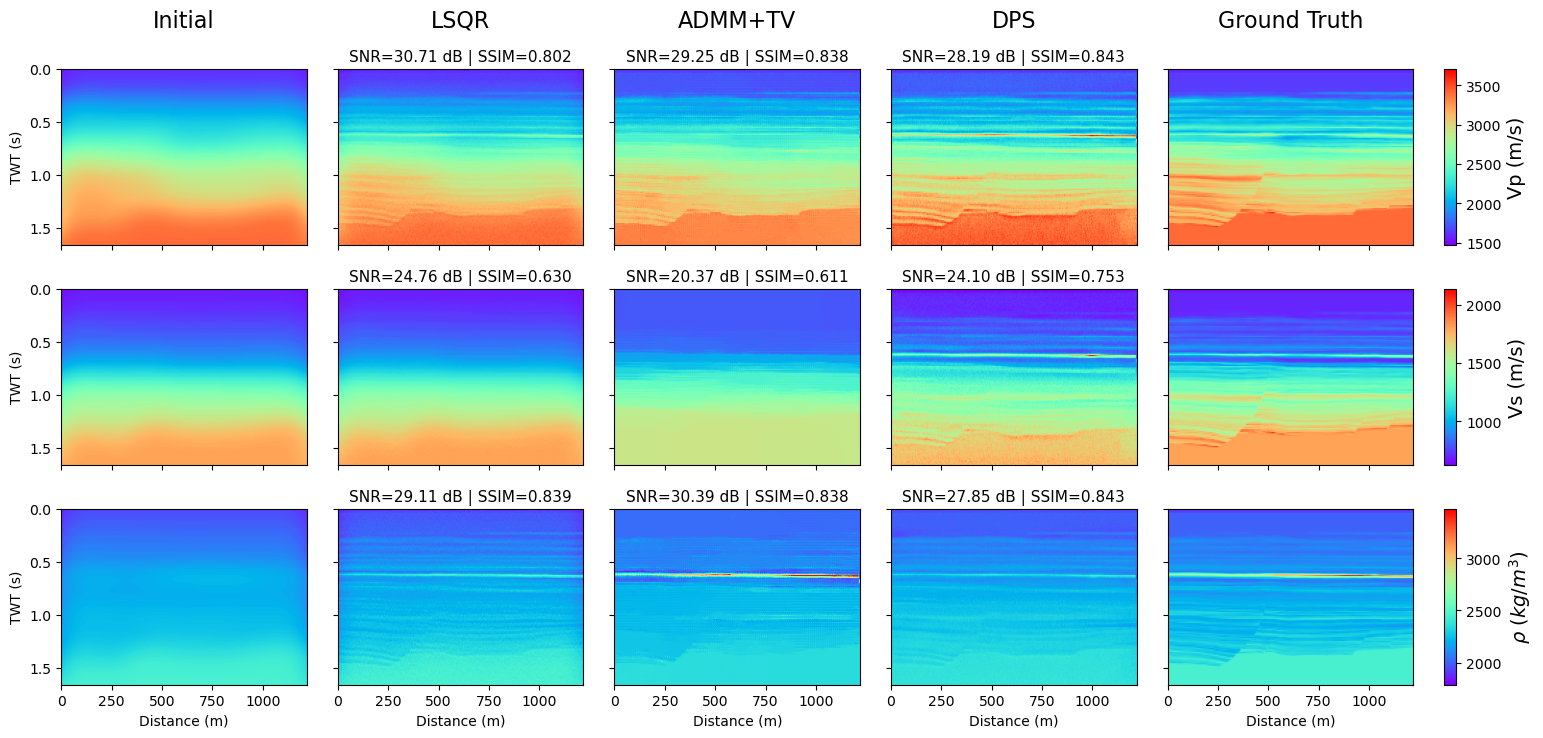

In [233]:
# plot for inverted 2D elastic model of otway data recovered using convnetional and DPS methods , which is out of distribution------------Fig. 2
import numpy as np
import matplotlib.pyplot as plt

titles = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ ($kg/m^3$)"]
col_titles = ["Initial", "LSQR", "ADMM+TV", "DPS", "Ground Truth"]

# --- Use an extra thin column for colorbars to keep all 5 panels same size ---
fig, axs = plt.subplots(
    3, 6, figsize=(18, 8),
    gridspec_kw={"width_ratios": [1, 1, 1, 1, 1, 0.05],
                 "wspace": 0.15, "hspace": 0.25},
    constrained_layout=False
)

# last column reserved for colorbars (one per row)
cax = axs[:, -1]

vmin_true = [vp.min(), vs.min(), rho.min()]
vmax_true = [vp.max(), vs.max(), rho.max()]

for i in range(3):

    gt = np.exp(m[:, i, :])

    img0 = np.exp(mback[:, i, :])
    img1 = minv_phy[i, :, :]
    img2 = madmmtv_phy[i, :, :]
    img3 = m_dps_final[i, :, :]
    img4 = gt

    imgs = [img0, img1, img2, img3, img4]

    ims = []
    for j in range(5):

        ax = axs[i, j]

        im = ax.imshow(
            imgs[j],
            aspect="auto",
            cmap="rainbow",
            vmin=vmin_true[i],
            vmax=vmax_true[i],
            extent=extent
        )
        ims.append(im)

        # --- Big column headers (only first row) ---
        if i == 0:
            ax.set_title(col_titles[j], fontsize=16, fontweight="normal", pad=30)

        # --- Compute metrics for methods (not for Initial or GT) ---
        if j in [1, 2, 3]:
            snr_val = snr_db(gt, imgs[j])
            ssim_score = ssim_val(gt, imgs[j])

            subtitle = f"\nSNR={snr_val:.2f} dB | SSIM={ssim_score:.3f}"
        else:
            subtitle = ""

        ax.text(
            0.5, 1.02,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=11
        )

        # --- Y ticks only first column ---
        if j != 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel("TWT (s)")

        # --- X ticks only last row ---
        if i != 2:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Distance (m)")

    cb = fig.colorbar(ims[-1], cax=cax[i])
    cb.set_label(titles[i], fontsize=14, fontweight="normal")


plt.show()

### 18. Well-comparison plotting function

In [234]:
# plot for inverted 1D trace at location 128 (612m, in distance) recovered using convnetional and DPS methods------------Fig. 3

import numpy as np
import matplotlib.pyplot as plt

def plot_vp_vs_rho_single_well(
    m_lsqr, m_admmtv, m_dps,
    vp_well, vs_well, rho_well,
    well_x,
    z=None,
    units=("m/s", "m/s", r"$kg/m^3$"),
    lw_true=1.5,
    lw_pred=1.8,
):
    """
    Expected (after squeezing):
      m_lsqr, m_admmtv, m_dps : (3, nz, nx)
      vp_well, vs_well, rho_well : (nz,)
      well_x : int
      z : (nz,)
    """

    # --- Squeeze possible leading singleton dims (e.g., (1,3,nz,nx) -> (3,nz,nx)) ---
    m_lsqr   = np.asarray(m_lsqr).squeeze()
    m_admmtv = np.asarray(m_admmtv).squeeze()
    m_dps    = np.asarray(m_dps).squeeze()

    if m_lsqr.ndim != 3 or m_lsqr.shape[0] != 3:
        raise ValueError(f"m_lsqr must be (3,nz,nx) after squeeze, got {m_lsqr.shape}")
    if m_admmtv.shape != m_lsqr.shape:
        raise ValueError(f"m_admmtv shape {m_admmtv.shape} != m_lsqr shape {m_lsqr.shape}")
    if m_dps.shape != m_lsqr.shape:
        raise ValueError(f"m_dps shape {m_dps.shape} != m_lsqr shape {m_lsqr.shape}")

    _, nz, nx = m_lsqr.shape

    # --- Force well_x to a scalar int ---
    well_x = int(np.asarray(well_x).squeeze())
    if not (0 <= well_x < nx):
        raise ValueError(f"well_x={well_x} out of bounds [0, {nx-1}]")

    # --- z axis ---
    if z is None:
        z = np.arange(nz)
    z = np.asarray(z).squeeze().ravel()
    if z.shape[0] != nz:
        raise ValueError(f"z must have length {nz}, got {z.shape[0]}")

    # --- Ensure well logs are 1D (nz,) ---
    vp_well  = np.asarray(vp_well).squeeze().ravel()
    vs_well  = np.asarray(vs_well).squeeze().ravel()
    rho_well = np.asarray(rho_well).squeeze().ravel()
    if vp_well.shape[0] != nz or vs_well.shape[0] != nz or rho_well.shape[0] != nz:
        raise ValueError(
            f"Well logs must be length nz={nz}. Got "
            f"vp {vp_well.shape}, vs {vs_well.shape}, rho {rho_well.shape}"
        )

    # --- Extract predicted profiles; squeeze to guarantee (nz,) ---
    vp_lsqr  = np.asarray(m_lsqr[0, :, well_x]).squeeze()
    vs_lsqr  = np.asarray(m_lsqr[1, :, well_x]).squeeze()
    rho_lsqr = np.asarray(m_lsqr[2, :, well_x]).squeeze()

    vp_admmtv  = np.asarray(m_admmtv[0, :, well_x]).squeeze()
    vs_admmtv  = np.asarray(m_admmtv[1, :, well_x]).squeeze()
    rho_admmtv = np.asarray(m_admmtv[2, :, well_x]).squeeze()

    vp_dps  = np.asarray(m_dps[0, :, well_x]).squeeze()
    vs_dps  = np.asarray(m_dps[1, :, well_x]).squeeze()
    rho_dps = np.asarray(m_dps[2, :, well_x]).squeeze()

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(12, 8), sharey=True)

    logs = [
        (vp_well,  vp_lsqr,  vp_admmtv,  vp_dps,  "Vp",  units[0]),
        (vs_well,  vs_lsqr,  vs_admmtv,  vs_dps,  "Vs",  units[1]),
        (rho_well, rho_lsqr, rho_admmtv, rho_dps, "Rho", units[2]),
    ]

    for ax, (true, lsqr, admmtv, dps, title, unit) in zip(axes, logs):
        ax.plot(true,   z, label="Well-log",    linewidth=lw_true, color="k", linestyle="--")
        ax.plot(lsqr,   z, label="LSQR",    linewidth=lw_pred)
        ax.plot(admmtv, z, label="ADMM+TV", linewidth=lw_pred)
        ax.plot(dps,    z, label="DPS",     linewidth=lw_pred)

        ax.set_title(f"{title} [{unit}]")
        ax.grid(True, alpha=0.3)
        ax.invert_yaxis()

    axes[0].set_ylabel("TWT (s)")
    
    #axes[0].set_xlabel("(m/s)")
    #axes[1].set_xlabel("(m/s)")
    #axes[2].set_xlabel(r"$(kg/m^3)$")

    axes[0].legend(loc="best")
    axes[1].legend(loc="best")
    axes[2].legend(loc="best")

    #fig.suptitle(f"Well comparison at x = {well_x}", y=1.02)
    fig.tight_layout()
    plt.show()


### 19. Run 1D trace comparison at trace ix=128 (~612 m)

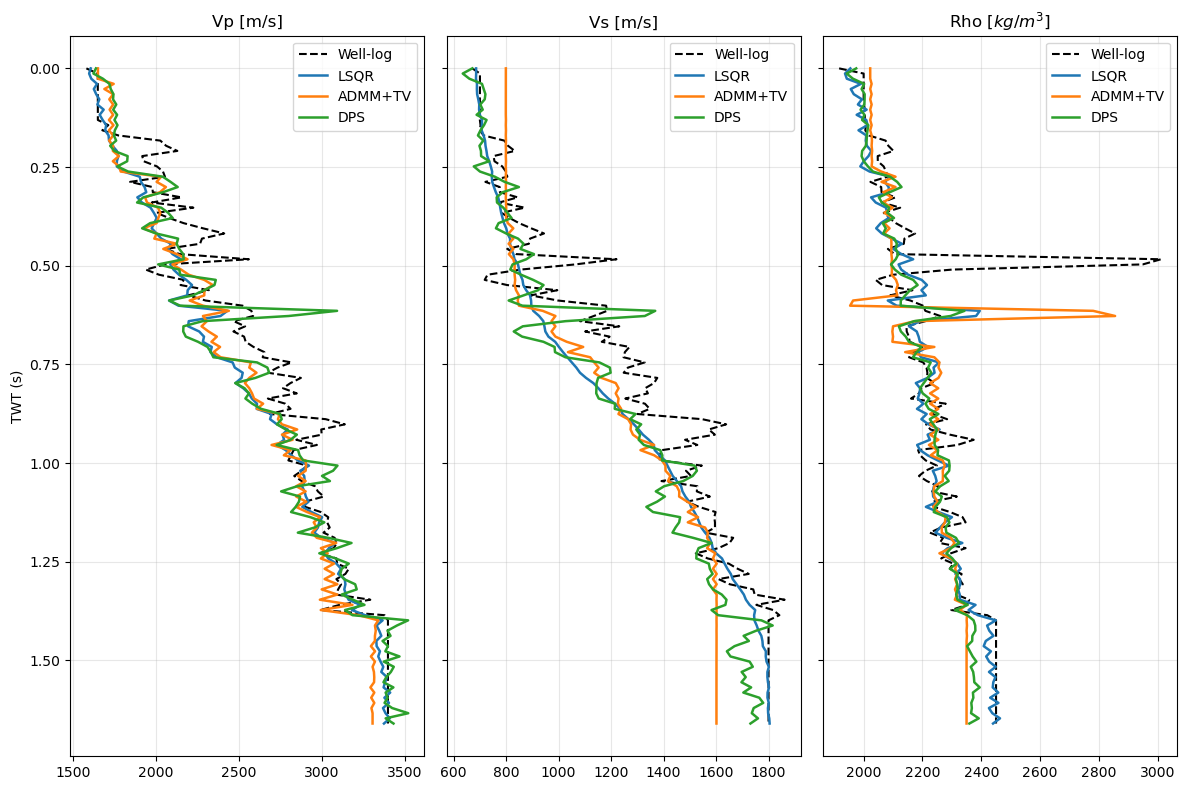

In [235]:

well_x = 128
z = np.arange(128) * z[1]-z[0]  # e.g. 5 m sampling

plot_vp_vs_rho_single_well(
    m_lsqr=minv_phy,
    m_admmtv=madmmtv_phy,
    m_dps=m_dps_final,
    vp_well=vp[:, well_x],
    vs_well=vs[:,well_x],
    rho_well=rho[:,well_x],
    well_x=well_x,
    z=t
)